In [1]:
from pathlib import Path

def find_project_root(start: Path, markers=("pyproject.toml", ".git")):
    for p in [start] + list(start.parents):
        if any((p / m).exists() for m in markers):
            return p
    raise RuntimeError("Project root not found")

ROOT = find_project_root(Path.cwd())

print(ROOT)

/home/urdatorn/git/gh/aristophanis-cantica


# Corpus

In [2]:
from aristophanis_cantica.stats import accentual_responsion_metric_corpus

accentual_responsion_stat = accentual_responsion_metric_corpus(ROOT / 'data/compiled')
print(f'Accentual responsion compatibility: {accentual_responsion_stat}')

Accentual responsion compatibility: {'acute': 0.2891070297656745, 'grave': 0.12490869247626005, 'circumflex': 0.17923823749066467, 'acute_circumflex': 0.25639315098954857}


# Play regression

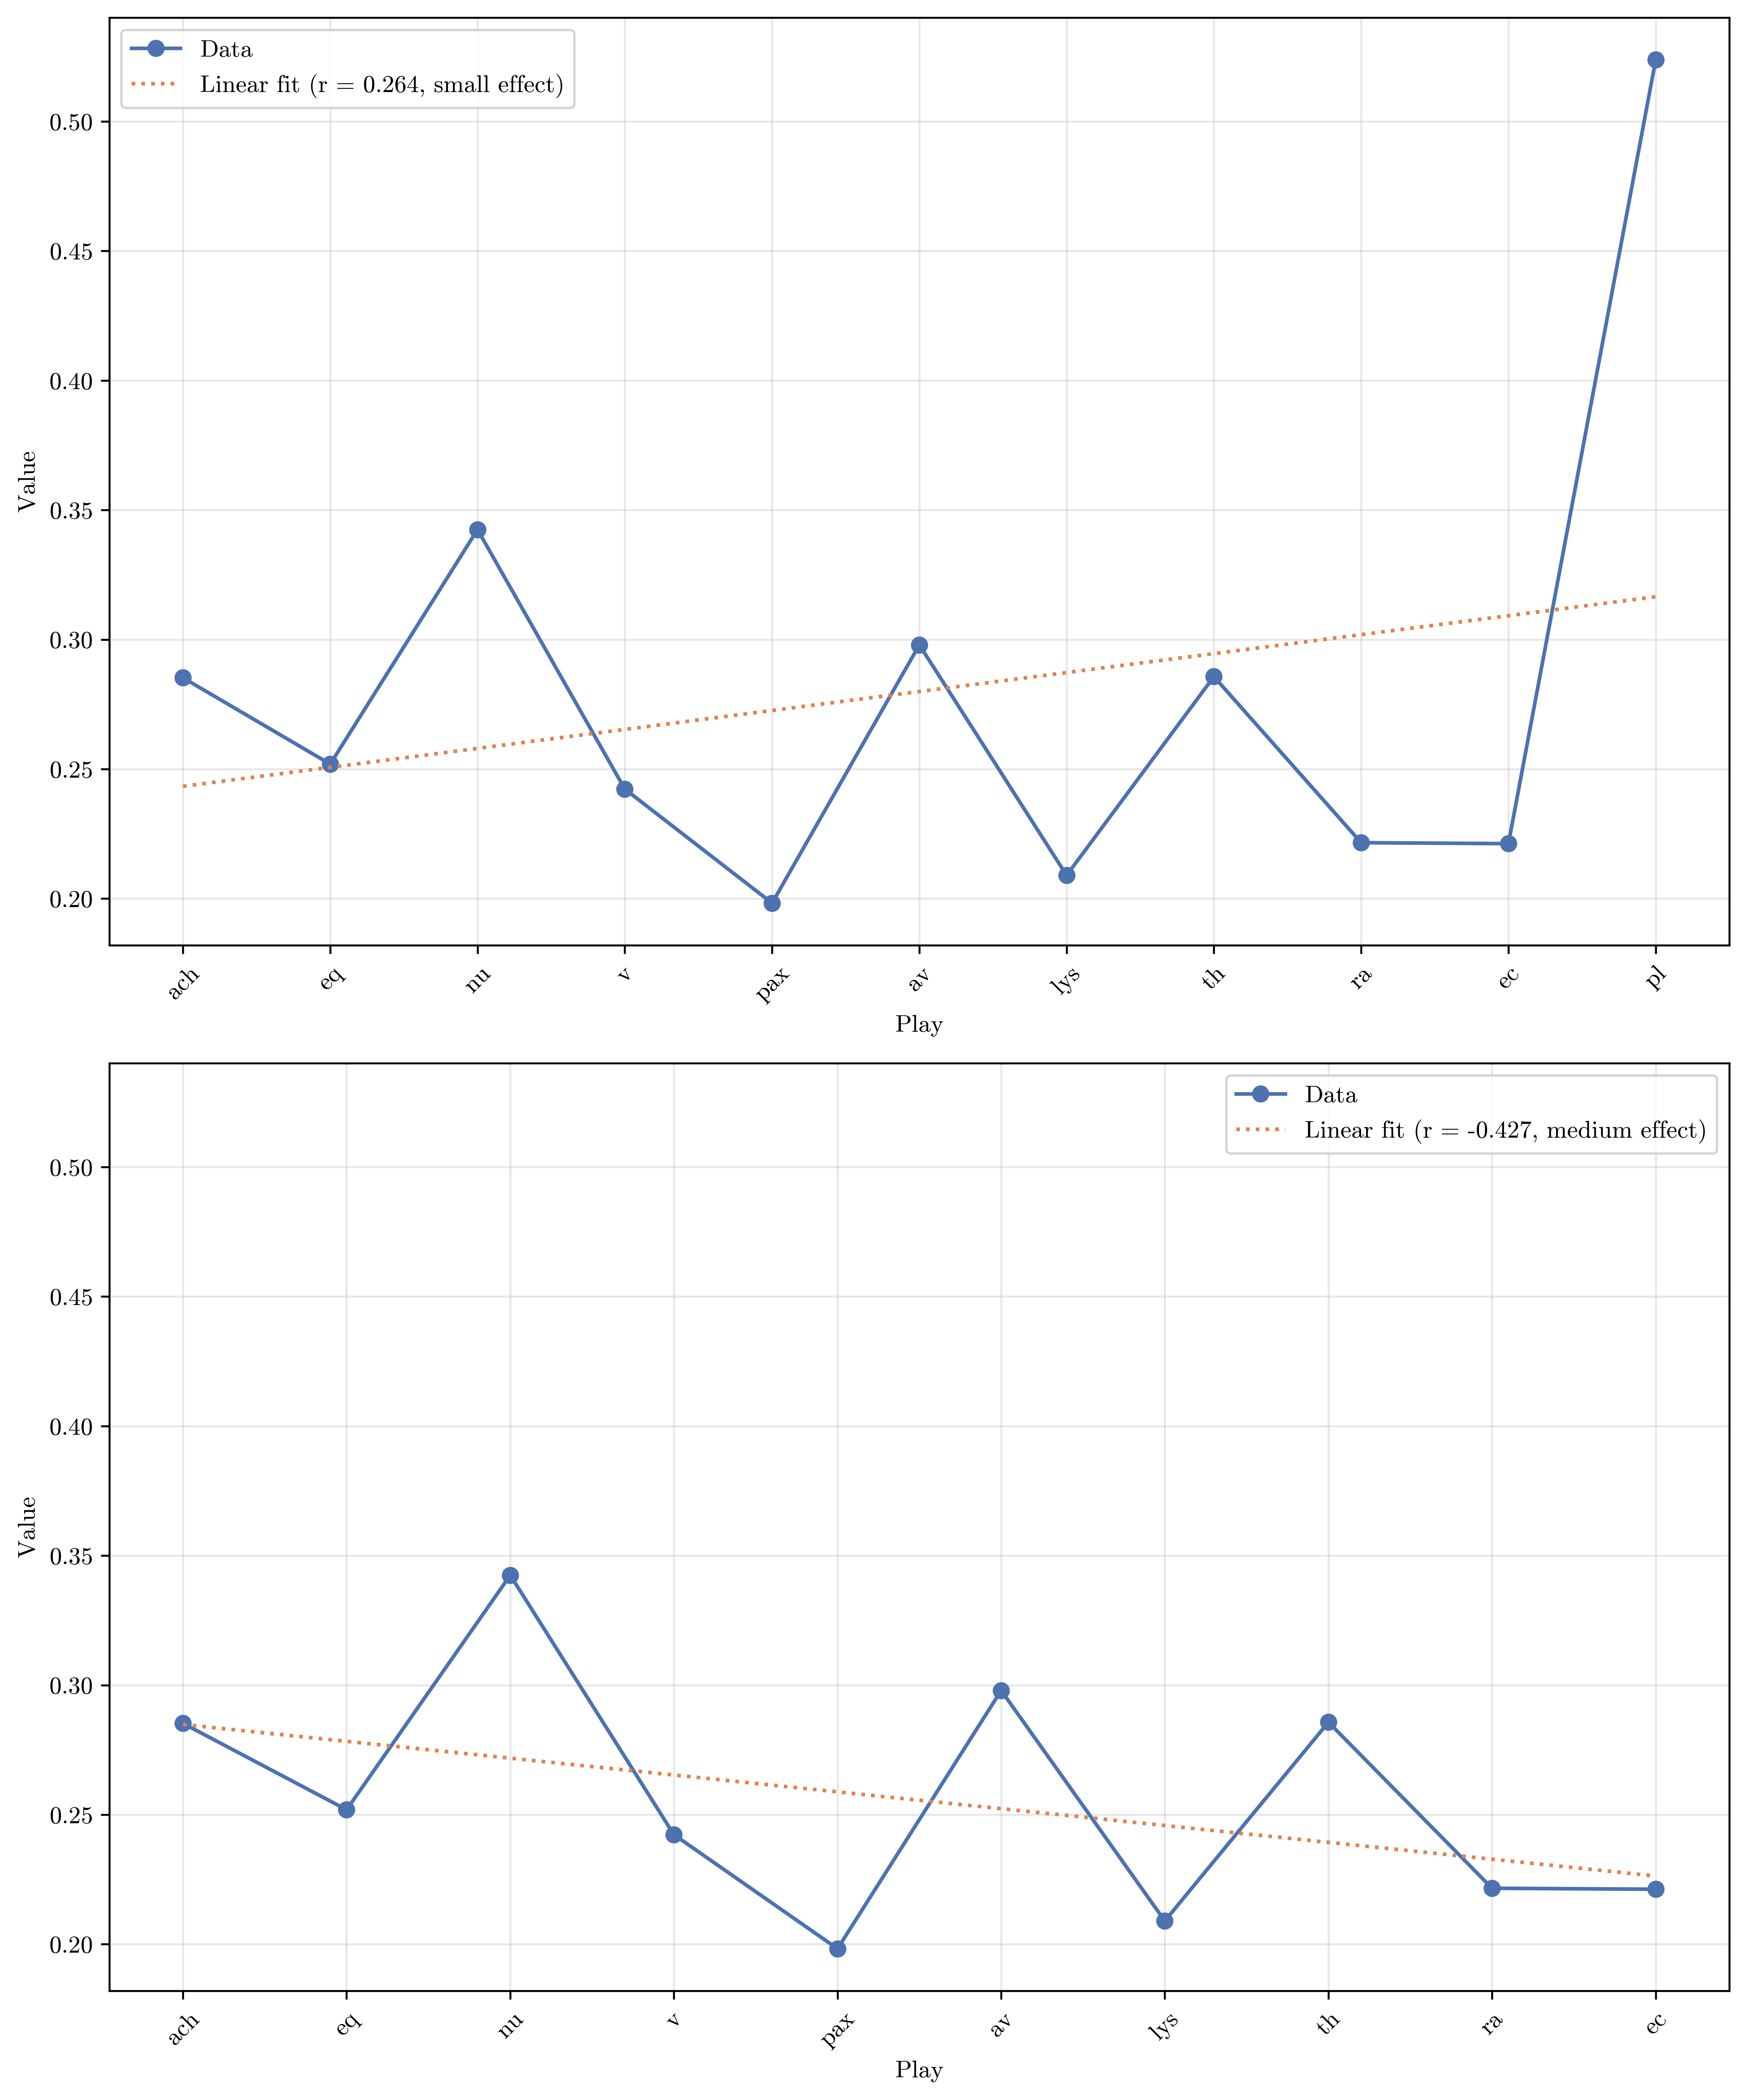

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

from aristophanis_cantica.plot import apply_plotting_poetry_palette
from aristophanis_cantica.stats import accentual_responsion_metric_play
from aristophanis_cantica.utils.utils import abbreviations, get_cohen_category

apply_plotting_poetry_palette()

abbreviations_no_pl = [abbrev for abbrev in abbreviations if abbrev != "pl"]

# ------------------------------------
# Settings
# ------------------------------------
metric = "acute_circumflex"
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]


# ------------------------------------
# Figure with two subplots
# ------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharey=True)


# ------------------------------------
# Top subplot: with Pl.
# ------------------------------------
play_stat_dictionary = {}

for play in abbreviations:
    xml_file = ROOT / f"data/compiled/responsion_{play}_compiled.xml"
    play_stat = accentual_responsion_metric_play(xml_file)
    play_stat_dictionary[play] = play_stat

data = play_stat_dictionary

x_labels = list(data.keys())
x_numeric = np.arange(len(x_labels), dtype=float)
y_values = np.array([data[key][metric] for key in x_labels], dtype=float)

slope, intercept, r_value, _, _ = linregress(x_numeric, y_values)
linear_fit = slope * x_numeric + intercept
cohen_category = get_cohen_category(r_value)

axes[0].plot(
    x_numeric,
    y_values,
    marker="o",
    color=default_colors[0],
    label="Data"
)

axes[0].plot(
    x_numeric,
    linear_fit,
    linestyle=":",
    color=default_colors[1],
    label=f"Linear fit (r = {r_value:.3f}, {cohen_category} effect)"
)

axes[0].set_xticks(x_numeric)
axes[0].set_xticklabels(x_labels, rotation=45)
axes[0].set_xlabel("Play")
axes[0].set_ylabel("Value")
axes[0].grid(True, alpha=0.3)
axes[0].legend()


# ------------------------------------
# Bottom subplot: without Pl.
# ------------------------------------
play_stat_dictionary = {}

for play in abbreviations_no_pl:
    xml_file = ROOT / f"data/compiled/responsion_{play}_compiled.xml"
    play_stat = accentual_responsion_metric_play(xml_file)
    play_stat_dictionary[play] = play_stat

data = play_stat_dictionary

x_labels = list(data.keys())
x_numeric = np.arange(len(x_labels), dtype=float)
y_values = np.array([data[key][metric] for key in x_labels], dtype=float)

slope, intercept, r_value, _, _ = linregress(x_numeric, y_values)
linear_fit = slope * x_numeric + intercept
cohen_category = get_cohen_category(r_value)

axes[1].plot(
    x_numeric,
    y_values,
    marker="o",
    color=default_colors[0],
    label="Data"
)

axes[1].plot(
    x_numeric,
    linear_fit,
    linestyle=":",
    color=default_colors[1],
    label=f"Linear fit (r = {r_value:.3f}, {cohen_category} effect)"
)

axes[1].set_xticks(x_numeric)
axes[1].set_xticklabels(x_labels, rotation=45)
axes[1].set_xlabel("Play")
axes[1].set_ylabel("Value")
axes[1].grid(True, alpha=0.3)
axes[1].legend()


plt.tight_layout()
plt.savefig(
    ROOT / "media/play_regression/linreg_orth.png",
    dpi=600
)
plt.show()

In [4]:
import matplotlib.pyplot as plt
from scipy.stats import linregress
from lxml import etree
from tabulate import tabulate
from aristophanis_cantica.plot import apply_plotting_poetry_palette
from aristophanis_cantica.stats import accentually_responding_syllables_of_strophes_polystrophic, count_all_accents_canticum
from aristophanis_cantica.utils.utils import abbreviations, get_canticum_ids
from scipy.stats import pearsonr

apply_plotting_poetry_palette()

def color_ratio(value):
    formatted = f"{value:.2f}"
    return f"[92m{formatted}[0m" if value > 0 else f"[91m{formatted}[0m"

canticum_ids = get_canticum_ids(abbreviations)
print(f"Number of cantica: {len(canticum_ids)}")
table_data = []

acute_ratios = []
grave_ratios = []
circumflex_ratios = []
pitch_ratios = []
labels = []

for idx, canticum in enumerate(canticum_ids):
    infix = canticum[:-2]
    xml_file = ROOT / f"data/compiled/responsion_{infix}_compiled.xml"
    tree = etree.parse(xml_file)

    strophes = tree.xpath(f'//*[self::strophe or self::antistrophe][@responsion="{canticum}"]')
    accent_maps = accentually_responding_syllables_of_strophes_polystrophic(*strophes)

    total_accent_sums = count_all_accents_canticum(tree, canticum)
    accent_responsion_counts = {
        'acute': sum(len(d) for d in accent_maps[0]),
        'grave': sum(len(d) for d in accent_maps[1]),
        'circumflex': sum(len(d) for d in accent_maps[2])
    }

    acute_total = total_accent_sums['acute']
    grave_total = total_accent_sums['grave']
    circumflex_total = total_accent_sums['circumflex']

    acute_stat = accent_responsion_counts['acute'] / acute_total if acute_total > 0 else 0
    grave_stat = accent_responsion_counts['grave'] / grave_total if grave_total > 0 else 0
    circumflex_stat = accent_responsion_counts['circumflex'] / circumflex_total if circumflex_total > 0 else 0

    pitch_numerator = accent_responsion_counts['acute'] + accent_responsion_counts['circumflex']
    pitch_denominator = acute_total + circumflex_total
    pitch_stat = pitch_numerator / pitch_denominator if pitch_denominator > 0 else 0

    table_data.append([
        canticum,
        f"{accent_responsion_counts['acute']} / {acute_total} = {color_ratio(acute_stat)}",
        f"{accent_responsion_counts['grave']} / {grave_total} = {color_ratio(grave_stat)}",
        f"{accent_responsion_counts['circumflex']} / {circumflex_total} = {color_ratio(circumflex_stat)}",
        f"{pitch_numerator} / {pitch_denominator} = {color_ratio(pitch_stat)}"
    ])

    labels.append(canticum)
    acute_ratios.append(acute_stat)
    grave_ratios.append(grave_stat)
    circumflex_ratios.append(circumflex_stat)
    pitch_ratios.append(pitch_stat)

# Print the table
print(tabulate(
    table_data,
    headers=["Canticum", "Acute", "Grave", "Circumflex", "Acute + Circumflex"],
    tablefmt="github"
))



Number of cantica: 78
| Canticum   | Acute           | Grave          | Circumflex     | Acute + Circumflex   |
|------------|-----------------|----------------|----------------|----------------------|
| ach01      | 18 / 62 = 0.29  | 4 / 27 = 0.15  | 8 / 32 = 0.25  | 26 / 94 = 0.28       |
| ach02      | 18 / 56 = 0.32  | 4 / 19 = 0.21  | 4 / 19 = 0.21  | 22 / 75 = 0.29       |
| ach03      | 12 / 31 = 0.39  | 0 / 11 = 0.00  | 6 / 12 = 0.50  | 18 / 43 = 0.42       |
| ach04      | 10 / 41 = 0.24  | 0 / 25 = 0.00  | 8 / 18 = 0.44  | 18 / 59 = 0.31       |
| ach05      | 0 / 28 = 0.00   | 0 / 12 = 0.00  | 0 / 16 = 0.00  | 0 / 44 = 0.00        |
| ach06      | 24 / 49 = 0.49  | 4 / 17 = 0.24  | 2 / 17 = 0.12  | 26 / 66 = 0.39       |
| ach07      | 26 / 101 = 0.26 | 4 / 44 = 0.09  | 10 / 33 = 0.30 | 36 / 134 = 0.27      |
| ach08      | 12 / 27 = 0.44  | 0 / 15 = 0.00  | 4 / 24 = 0.17  | 16 / 51 = 0.31       |
| ach09      | 16 / 50 = 0.32  | 0 / 17 = 0.00  | 2 / 15 = 0.13  | 18 / 65 = 0